1.LOAD DATASET

In [1]:
import pandas as pd

PLATFORM = "Instagram"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(24156, 56)
(6039, 56)


In [2]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    19313
1     4843
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.951151
1    20.048849
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    4828
1    1211
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.947011
1    20.052989
Name: proportion, dtype: float64


In [3]:
# 1. Tính TỰ ĐỘNG tỷ lệ Ratio dựa trên tập Train
# Công thức chuẩn của XGBoost: sum(negative instances) / sum(positive instances)
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Đã kích hoạt chống lười! Trọng số scale_pos_weight = {ratio:.2f}")

Đã kích hoạt chống lười! Trọng số scale_pos_weight = 3.99


In [4]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [13]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# 2. Khởi tạo XGBoost kết hợp Combo: Chống lười (Ratio) + Chống Overfit (Colsample)
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    # CHỐNG LƯỜI (Của bạn bà)
    scale_pos_weight=ratio,      
    
    # CÁC THAM SỐ CÂY TỐI ƯU
    n_estimators=300,            # 300 - 500 đều ok
    learning_rate=0.05,          
    max_depth=5,                 # Giữ ở 5-6 thôi
    
    # CHỐNG ĐỘC TÀI & OVERFIT (Của tui)
    subsample=0.8,               
    colsample_bytree=0.5,        # Ép model phải học Graph Features
    colsample_bylevel=0.5,
    reg_alpha=1.0,               # Phạt L1
    reg_lambda=2.0,              # Phạt L2
    
    random_state=42,
    n_jobs=-1
)

In [14]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,0.5
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [15]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [16]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [17]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      4828
           1       0.48      0.77      0.59      1211

    accuracy                           0.78      6039
   macro avg       0.70      0.78      0.72      6039
weighted avg       0.84      0.78      0.80      6039

ROC-AUC  : 0.8688


In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[3807 1021]
 [ 283  928]]


In [19]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.322776
5              verified    0.114780
31         topic_Sports    0.014182
10       toxicity_score    0.013806
24        topic_Fashion    0.013311
4      account_age_days    0.013132
9    sentiment_negative    0.013062
8    sentiment_positive    0.013034
32     topic_Technology    0.012734
27         topic_Gaming    0.012728
21        topic_Climate    0.012681
18  sentiment_intensity    0.012634
6        content_length    0.012505
22      topic_Education    0.012345
42     language_Spanish    0.012011


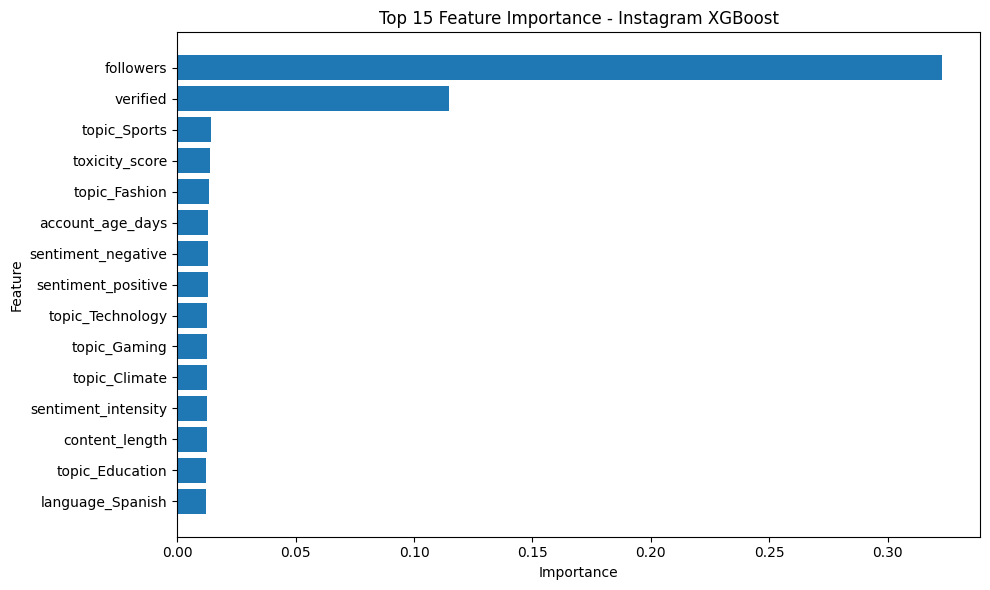

In [20]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Instagram XGBoost"
)

plt.tight_layout()

plt.show()